In [25]:
import pandas as pd

df = pd.read_csv("../data/student-mat.csv", sep=';')

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [26]:
# Shape of dataset
print("Dataset Shape:")
print(df.shape)

# Column names
print("\nColumn Names:")
print(df.columns)

# Data information
print("\nDataset Info:")
df.info()

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(395, 33)

Column Names:
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob      

In [27]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

# Confirm new shape
print("New Dataset Shape:", df.shape)

Duplicate Rows: 0
New Dataset Shape: (395, 33)


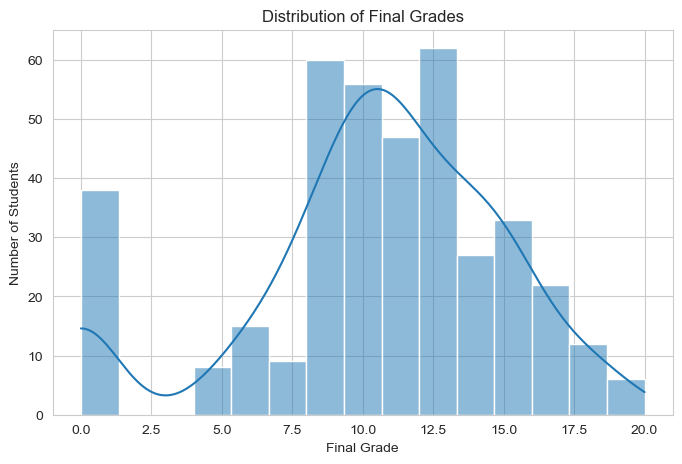

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

# Create figure
plt.figure(figsize=(8,5))

# Plot grade distribution
sns.histplot(df['G3'], bins=15, kde=True)

# Titles
plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")

plt.savefig("../images/grade_distribution.png")

# Show graph
plt.show()

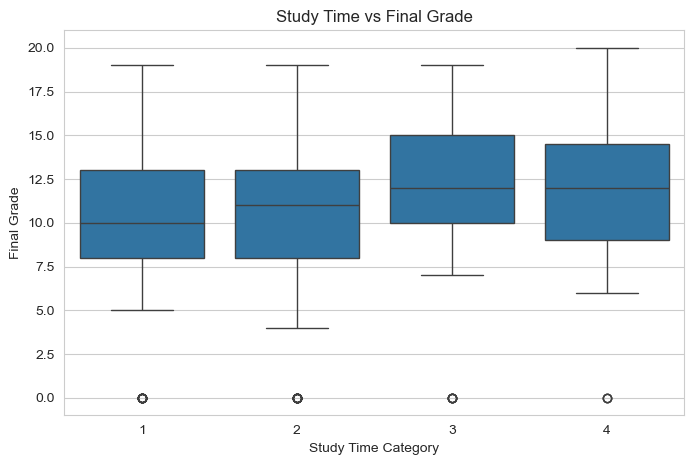

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(x='studytime', y='G3', data=df)

plt.title("Study Time vs Final Grade")

plt.xlabel("Study Time Category")
plt.ylabel("Final Grade")
plt.savefig("../images/studytime_vs_grade.png")
plt.show()

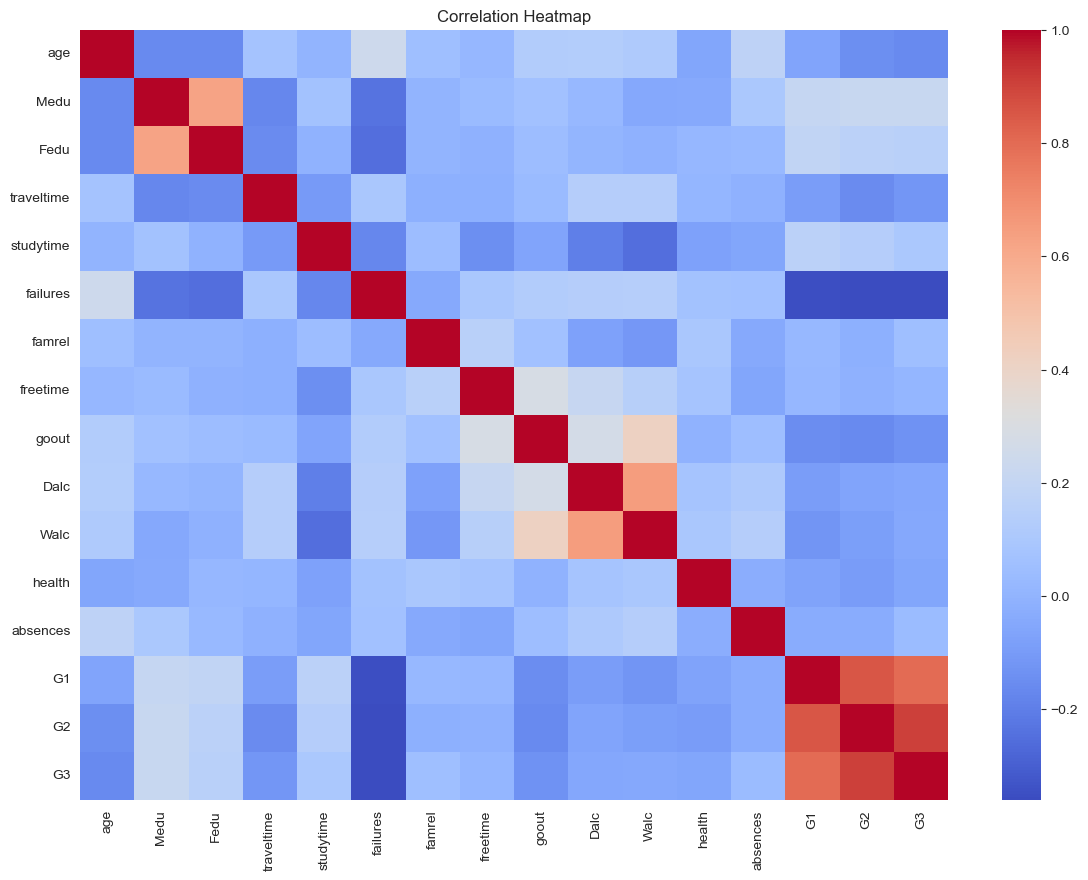

In [30]:
# Select only numerical columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Create correlation matrix
correlation = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(14,10))

sns.heatmap(
    correlation,
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Heatmap")
plt.savefig("../images/heatmap.png")

plt.show()

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Create copy
data = df.copy()

# Encode categorical columns
label_encoder = LabelEncoder()

for column in data.columns:
    if data[column].dtype == 'object':
        data[column] = label_encoder.fit_transform(data[column])

# Features
X = data.drop('G3', axis=1)

# Target
y = data['G3']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (316, 32)
Testing set shape: (79, 32)


In [32]:
from sklearn.linear_model import LinearRegression

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [33]:
# Predict results
predictions = model.predict(X_test)

# Display predictions
print(predictions[:10])

[ 6.28152491 11.32691676  3.03252133  8.03726136  8.55577788 12.36703933
 18.68481592  7.54069216  6.98823227 12.36020452]


In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Metrics
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Absolute Error: 1.4954750100522758
Mean Squared Error: 5.0323941088667405
R2 Score: 0.75457778550435


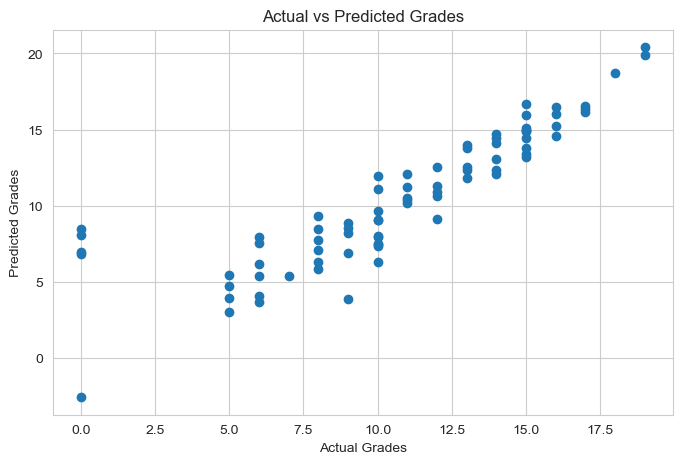

In [35]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Grades")
plt.ylabel("Predicted Grades")

plt.title("Actual vs Predicted Grades")

plt.savefig("../images/actual_vs_predicted.png")
plt.show()




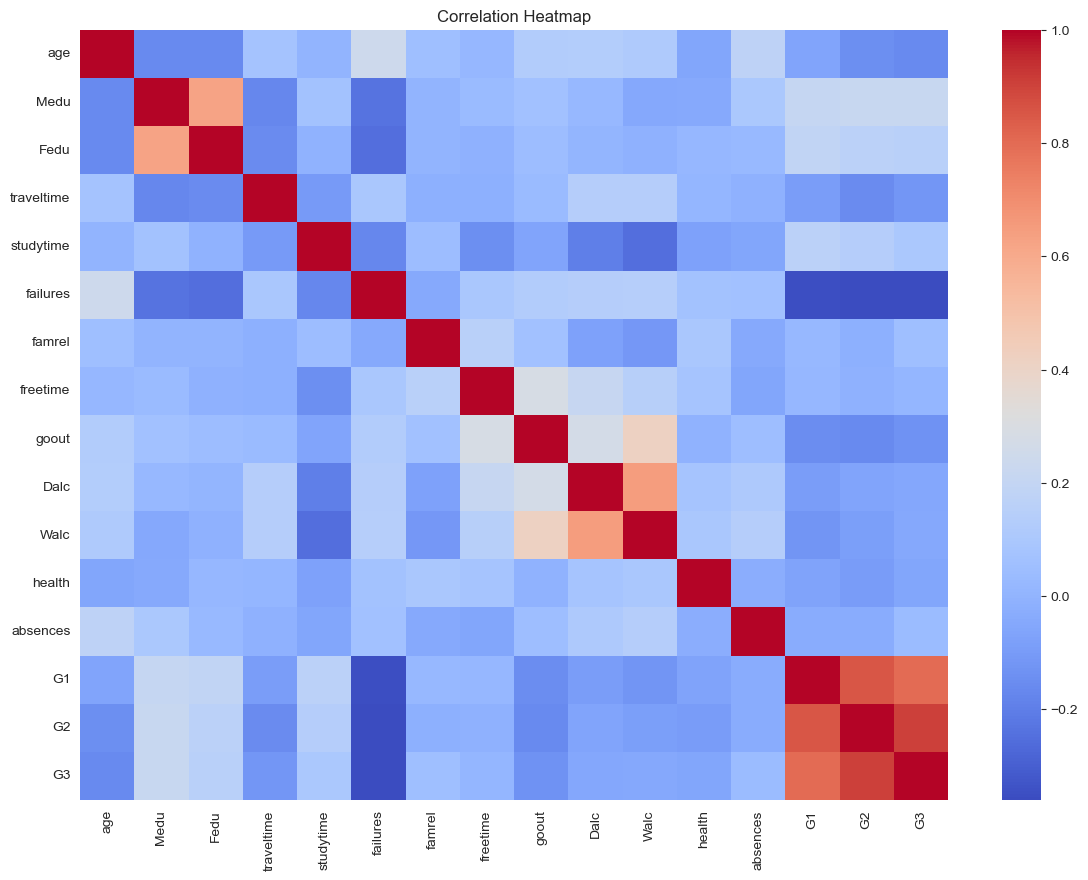

In [36]:
# Select only numerical columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Create correlation matrix
correlation = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(14,10))

sns.heatmap(
    correlation,
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()


In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Create copy
data = df.copy()

# Encode categorical columns
label_encoder = LabelEncoder()

for column in data.columns:
    if data[column].dtype == 'object':
        data[column] = label_encoder.fit_transform(data[column])

# Features
X = data.drop('G3', axis=1)

# Target
y = data['G3']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (316, 32)
Testing set shape: (79, 32)


In [38]:
from sklearn.linear_model import LinearRegression

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [39]:
# Predict results
predictions = model.predict(X_test)

# Display predictions
print(predictions[:10])

[ 6.28152491 11.32691676  3.03252133  8.03726136  8.55577788 12.36703933
 18.68481592  7.54069216  6.98823227 12.36020452]


In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Metrics
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Absolute Error: 1.4954750100522758
Mean Squared Error: 5.0323941088667405
R2 Score: 0.75457778550435


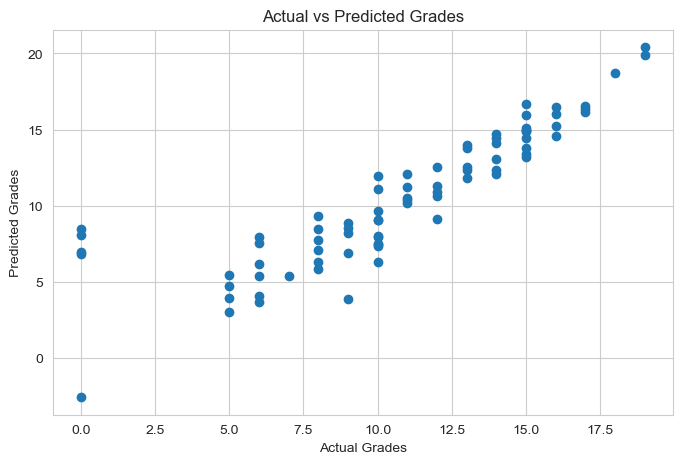

In [41]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Grades")
plt.ylabel("Predicted Grades")

plt.title("Actual vs Predicted Grades")

plt.show()

In [42]:
# Get feature importance using coefficients
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_
})

# Sort values
importance = importance.sort_values(
    by='Importance',
    ascending=False
)

# Display top features
print(importance.head(10))

       Feature  Importance
31          G2    0.954569
15   schoolsup    0.750961
1          sex    0.293869
23      famrel    0.289210
30          G1    0.206123
16      famsup    0.176043
25       goout    0.171814
12  traveltime    0.140033
20      higher    0.139570
6         Medu    0.115051


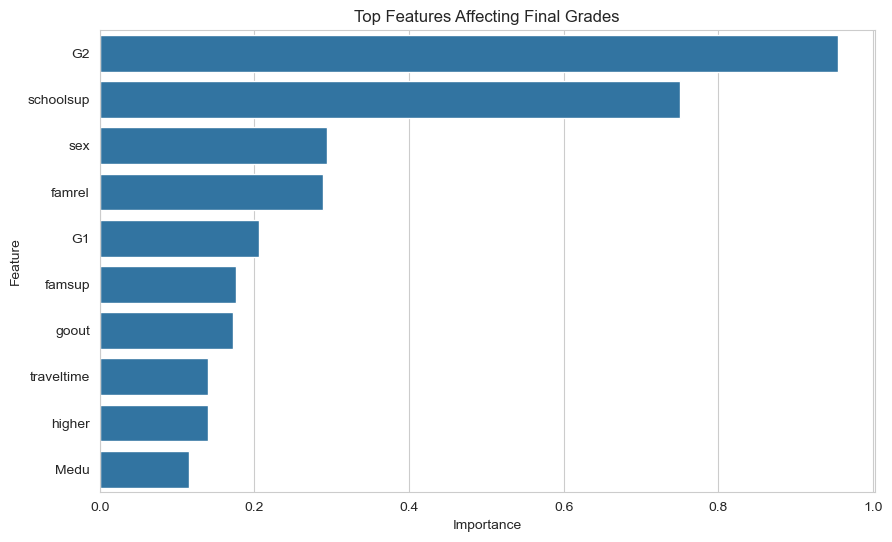

In [43]:
# Plot feature importance
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title("Top Features Affecting Final Grades")

plt.savefig("../images/feature_importance.png")
plt.show()

In [44]:
from sklearn.ensemble import RandomForestRegressor

# Create model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
rf_predictions = rf_model.predict(X_test)

print("Random Forest Model Trained.")

Random Forest Model Trained.


In [45]:
# Evaluate Random Forest
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest MAE:", rf_mae)
print("Random Forest R2 Score:", rf_r2)

Random Forest MAE: 1.1050632911392408
Random Forest R2 Score: 0.8299569015097052


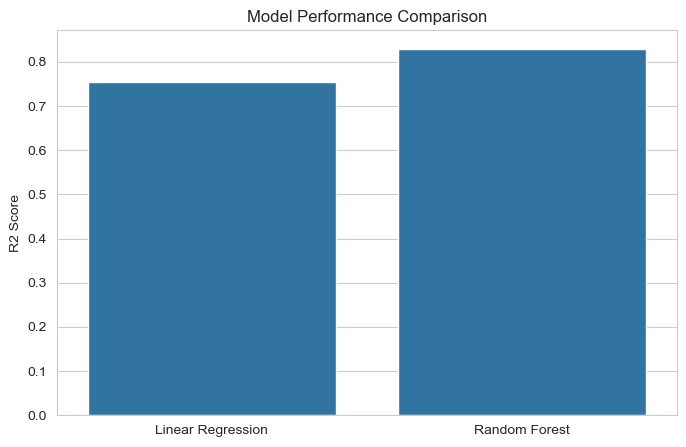

In [46]:
# Model comparison
models = ['Linear Regression', 'Random Forest']
scores = [r2, rf_r2]

plt.figure(figsize=(8,5))

sns.barplot(x=models, y=scores)

plt.ylabel("R2 Score")
plt.title("Model Performance Comparison")

plt.savefig("../images/model_comparison.png")

plt.show()

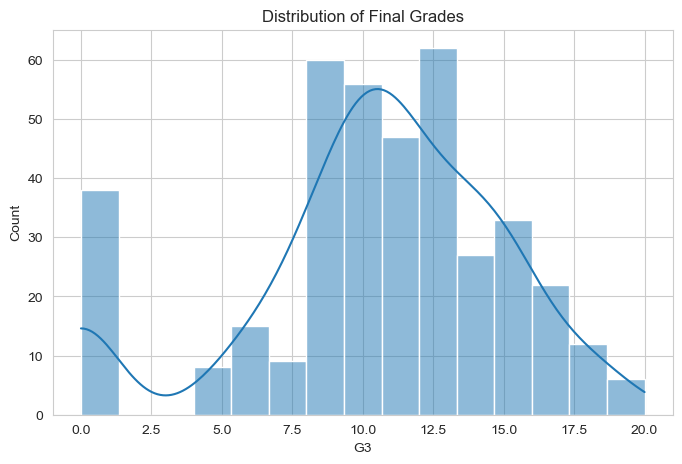

In [47]:
plt.figure(figsize=(8,5))

sns.histplot(df['G3'], bins=15, kde=True)

plt.title("Distribution of Final Grades")

plt.savefig("../images/grade_distribution.png")

plt.show()